# Week 10 · Feature Engineering
## PCA · Correlation Analysis · Feature Selection · Dimensionality Reduction

**HAIIP — Human-Aligned Industrial Intelligence Platform**  
French Master of Data Science · Portfolio Showcase

---

### Objective

Raw sensor data from industrial machines is high-dimensional, redundant, and noisy.  
Feature engineering transforms it into a compact, informative representation.

**Curse of Dimensionality**: In $p$ dimensions, the volume grows as $r^p$ → data becomes sparse → distance-based methods degrade.

### Pipeline
```
Raw Signals → Time-Domain Features → Correlation Filter → PCA → Model
                                    ↓
                             SHAP / RFE Selection
```

### Dataset
Simulated turbofan sensor array: 21 raw signals (CMAPSS-inspired) → extract features, reduce to 5–8 informative dimensions.

In [1]:
# !pip install numpy pandas scikit-learn matplotlib seaborn shap

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif,
    RFE, SelectFromModel
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
print('Libraries loaded.')

Libraries loaded.


In [3]:
def simulate_turbofan_sensors(n=1200, seed=42):
    rng = np.random.default_rng(seed)
    # 5 truly informative signals
    T_exhaust = rng.normal(550, 20, n)
    fuel_ratio = rng.normal(1.3, 0.08, n)
    bypass     = rng.normal(14.6, 0.5, n)
    vibration  = rng.normal(0.5, 0.1, n)
    pressure   = rng.normal(300, 15, n)

    # Label: failure if degradation score exceeds threshold
    score = (T_exhaust - 550)/20 - (bypass - 14.6)/0.5 + vibration/0.1
    y = (score > 1.5).astype(int)

    # 16 redundant / noisy signals
    X = np.column_stack([
        T_exhaust, fuel_ratio, bypass, vibration, pressure,
        T_exhaust + rng.normal(0, 5, n),     # near-duplicate
        fuel_ratio * 0.98 + rng.normal(0, 0.01, n),  # near-duplicate
        T_exhaust + bypass + rng.normal(0, 3, n),     # linear combo
        pressure * 0.5 + rng.normal(0, 5, n),
        bypass ** 2 / 10 + rng.normal(0, 0.5, n),
        *[rng.normal(0, 1, n) for _ in range(11)]     # pure noise
    ])

    cols = [f'S{i+1:02d}' for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=cols)
    df['failure'] = y
    return df

df = simulate_turbofan_sensors()
print(f'Dataset: {df.shape}  |  failure rate: {df["failure"].mean()*100:.1f}%')
df.head()

Dataset: (1200, 22)  |  failure rate: 98.2%


,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10,...,S13,S14,S15,S16,S17,S18,S19,S20,S21,failure
0,556.094342,1.194197,14.376965,0.596825,300.378942,557.219925,1.178780,569.036295,149.977707,20.683039,...,1.468047,0.791141,0.887126,0.636265,0.254521,-0.038106,0.753779,0.436883,-0.422500,1
1,529.200318,1.261104,15.090095,0.741781,308.140145,528.933603,1.243272,547.767703,157.354490,22.493314,...,-0.059823,-0.563177,-1.172666,1.579594,-0.636993,1.567228,1.303578,1.586287,0.969549,1
2,565.009024,1.333618,14.740587,0.361048,299.784990,569.329242,1.312321,578.571398,154.073486,21.469566,...,-1.213616,0.834434,0.063155,-0.668791,-1.515602,-0.756832,0.173557,-0.971857,-0.432650,1
3,568.811294,1.291808,14.251221,0.645817,314.609945,571.844960,1.266708,584.958245,157.846061,20.028118,...,0.392103,1.235947,1.339641,-0.545453,-0.352116,0.799052,1.979803,0.189646,0.354970,1
4,510.979296,1.247955,14.167030,0.507014,293.070972,496.050184,1.217752,525.685013,151.314654,19.833572,...,-0.177655,-0.841387,-1.274932,-0.208867,1.282919,0.316442,-1.320971,0.855873,-0.125404,1


## 1 · Correlation Analysis

**Pearson correlation** between features $X_i$ and $X_j$:
$$\rho_{ij} = \frac{\text{Cov}(X_i, X_j)}{\sigma_{X_i} \sigma_{X_j}} \in [-1, 1]$$

**Feature-target correlation** (point-biserial for binary target):
$$r_{pb} = \frac{\bar{X}_1 - \bar{X}_0}{s_X} \sqrt{\frac{n_1 n_0}{n^2}}$$

**Clustering strategy**: remove one feature from each highly correlated pair ($|\rho| > 0.9$)  
→ reduces multicollinearity, improves model stability.

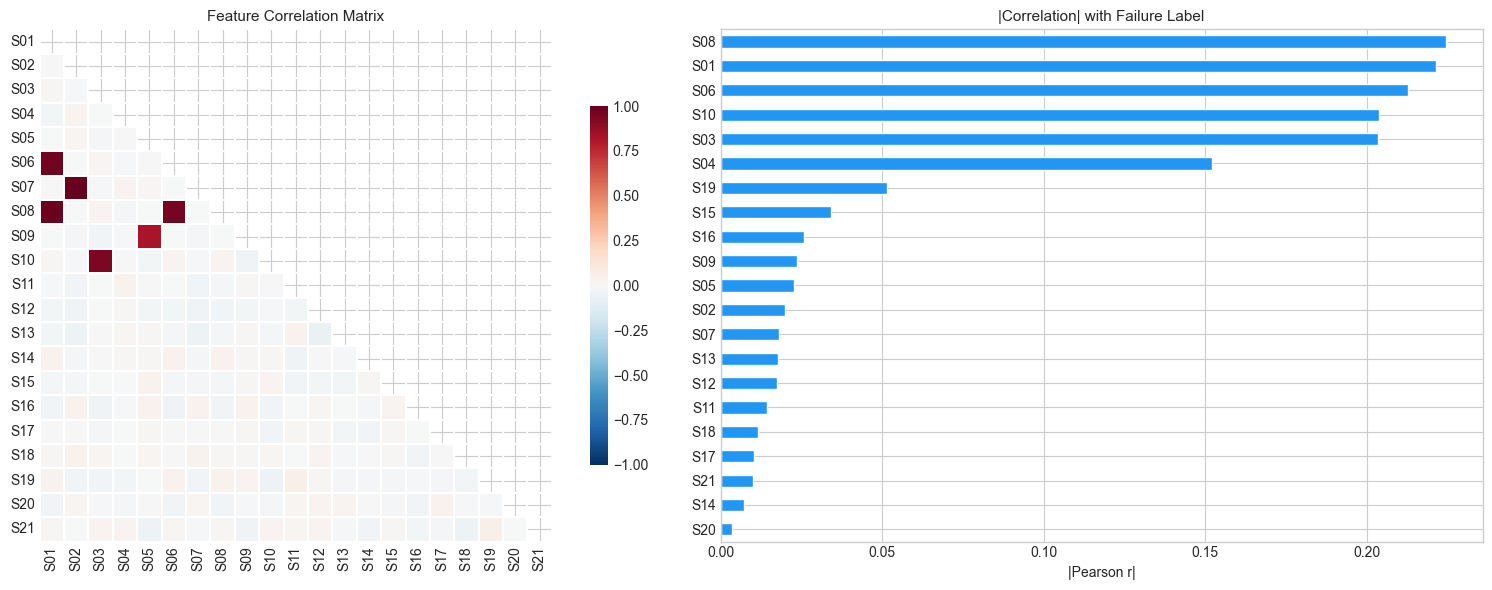


Dropped 4 correlated features: ['S06', 'S07', 'S08', 'S10']
Remaining features: 17


In [4]:
feature_cols = [c for c in df.columns if c != 'failure']
X = df[feature_cols].values
y = df['failure'].values

corr_matrix = df[feature_cols].corr()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax1, square=True, linewidths=0.3, cbar_kws={'shrink': 0.7})
ax1.set_title('Feature Correlation Matrix', fontsize=11)

# Feature-target correlation
target_corr = df[feature_cols].corrwith(df['failure']).abs().sort_values(ascending=True)
target_corr.plot(kind='barh', ax=ax2, color=PALETTE[0], edgecolor='white')
ax2.set_title('|Correlation| with Failure Label', fontsize=11)
ax2.set_xlabel('|Pearson r|')

plt.tight_layout()
plt.savefig('plots/10_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Remove highly correlated pairs
def remove_correlated(X_df, threshold=0.9):
    corr = X_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > threshold)]
    return X_df.drop(columns=to_drop), to_drop

df_filtered, dropped = remove_correlated(df[feature_cols])
print(f'\nDropped {len(dropped)} correlated features: {dropped}')
print(f'Remaining features: {df_filtered.shape[1]}')

## 2 · Principal Component Analysis (PCA)

### Mathematical Foundation

PCA finds an orthogonal linear transformation $\mathbf{W} \in \mathbb{R}^{p \times k}$ that maximises variance:

$$\mathbf{Z} = \mathbf{X} \mathbf{W}, \quad \text{where} \quad \mathbf{W} = \text{eigenvectors of } \mathbf{\Sigma}_X$$

**Covariance matrix eigendecomposition:**
$$\mathbf{\Sigma}_X = \frac{1}{n-1} \mathbf{X}^\top \mathbf{X} = \mathbf{V} \mathbf{\Lambda} \mathbf{V}^\top$$

The $j$-th principal component $\mathbf{v}_j$ (eigenvector) explains variance $\lambda_j$ (eigenvalue).

**Explained variance ratio:**
$$\text{EVR}_j = \frac{\lambda_j}{\sum_i \lambda_i}$$

**Reconstruction error** for $k$ components:
$$\|\mathbf{X} - \hat{\mathbf{X}}\|_F^2 = \sum_{j=k+1}^{p} \lambda_j$$

**Key property**: PCA is the solution to the linear autoencoder problem (Week 7 connection).

PCA Summary:
  Components for 90% variance: 14
  Components for 95% variance: 16
  PC1 explained variance: 14.1%
  PC2 explained variance: 9.6%


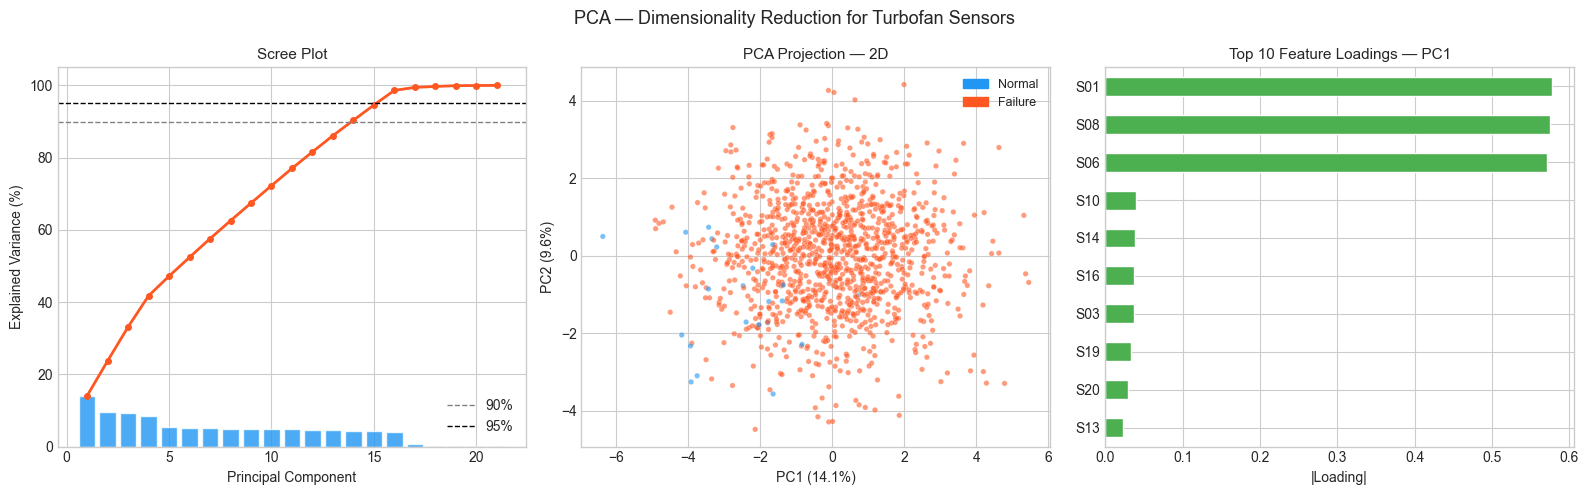

In [5]:
scaler = StandardScaler()
X_s = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_s)

evr = pca_full.explained_variance_ratio_
cumulative_evr = np.cumsum(evr)
n_components_90 = np.argmax(cumulative_evr >= 0.90) + 1
n_components_95 = np.argmax(cumulative_evr >= 0.95) + 1

print(f'PCA Summary:')
print(f'  Components for 90% variance: {n_components_90}')
print(f'  Components for 95% variance: {n_components_95}')
print(f'  PC1 explained variance: {evr[0]*100:.1f}%')
print(f'  PC2 explained variance: {evr[1]*100:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scree plot
axes[0].bar(range(1, len(evr)+1), evr*100, color=PALETTE[0], alpha=0.8, edgecolor='white')
axes[0].plot(range(1, len(evr)+1), cumulative_evr*100, 'o-', color=PALETTE[1], linewidth=2, markersize=4)
axes[0].axhline(90, color='gray', linestyle='--', linewidth=1, label='90%')
axes[0].axhline(95, color='black', linestyle='--', linewidth=1, label='95%')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot', fontsize=11); axes[0].legend()

# PC1 vs PC2 scatter
pca2 = PCA(n_components=2).fit_transform(X_s)
colors = [PALETTE[0] if yi == 0 else PALETTE[1] for yi in y]
axes[1].scatter(pca2[:, 0], pca2[:, 1], c=colors, alpha=0.6, s=15, edgecolors='white', linewidth=0.2)
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color=PALETTE[0], label='Normal'), Patch(color=PALETTE[1], label='Failure')], fontsize=9)
axes[1].set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
axes[1].set_title('PCA Projection — 2D', fontsize=11)

# Loadings (feature contributions to PC1)
loadings = pd.Series(pca_full.components_[0], index=feature_cols).abs().sort_values(ascending=True)
loadings.tail(10).plot(kind='barh', ax=axes[2], color=PALETTE[2], edgecolor='white')
axes[2].set_title('Top 10 Feature Loadings — PC1', fontsize=11)
axes[2].set_xlabel('|Loading|')

plt.suptitle('PCA — Dimensionality Reduction for Turbofan Sensors', fontsize=13)
plt.tight_layout()
plt.savefig('plots/10_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 · Feature Selection Methods

### 3.1 Filter Methods — Mutual Information

Mutual information measures statistical dependence (captures non-linear relationships unlike correlation):

$$\text{MI}(X_j; Y) = \sum_{x, y} p(x, y) \log \frac{p(x, y)}{p(x)p(y)}$$

$\text{MI} = 0$ iff $X_j \perp Y$. Estimated via $k$-NN density estimation (Kraskov et al., 2004).

### 3.2 Wrapper Methods — Recursive Feature Elimination (RFE)

Iteratively trains model → removes least important feature → repeat until $k$ features remain.  
Cost: $O(p)$ model fits — feasible for $p < 100$.

### 3.3 Embedded Methods — L1 / Tree Importance

Regularized models perform selection during training:  
- **Lasso** ($L_1$): $\mathcal{L} + \lambda \|\mathbf{w}\|_1$ → sparse solutions  
- **Tree importance**: $\sum_t \Delta G(t) \cdot \frac{|t|}{n}$ (built-in, fast)

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline: all features
rf_base = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)
baseline_f1 = cross_val_score(rf_base, X_s, y, cv=cv, scoring='f1').mean()
print(f'Baseline (all {X_s.shape[1]} features): F1={baseline_f1:.4f}')

# 1. Mutual Information filter (top 8)
mi_selector = SelectKBest(mutual_info_classif, k=8)
X_mi = mi_selector.fit_transform(X_s, y)
mi_f1 = cross_val_score(rf_base, X_mi, y, cv=cv, scoring='f1').mean()
mi_features = [feature_cols[i] for i in mi_selector.get_support(indices=True)]
print(f'MI filter (k=8):  F1={mi_f1:.4f}  features={mi_features}')

# 2. RFE (top 8)
rfe = RFE(RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42), n_features_to_select=8)
X_rfe = rfe.fit_transform(X_s, y)
rfe_f1 = cross_val_score(rf_base, X_rfe, y, cv=cv, scoring='f1').mean()
rfe_features = [feature_cols[i] for i, s in enumerate(rfe.support_) if s]
print(f'RFE (k=8):        F1={rfe_f1:.4f}  features={rfe_features}')

# 3. PCA (k=8 components)
pca8 = PCA(n_components=8)
X_pca8 = pca8.fit_transform(X_s)
pca_f1 = cross_val_score(rf_base, X_pca8, y, cv=cv, scoring='f1').mean()
print(f'PCA (k=8):        F1={pca_f1:.4f}  (captures {pca8.explained_variance_ratio_.sum()*100:.1f}% variance)')

Baseline (all 21 features): F1=0.9907


MI filter (k=8):  F1=0.9928  features=['S01', 'S02', 'S03', 'S04', 'S06', 'S08', 'S10', 'S16']


RFE (k=8):        F1=0.9928  features=['S01', 'S03', 'S04', 'S06', 'S08', 'S09', 'S10', 'S21']


PCA (k=8):        F1=0.9907  (captures 62.5% variance)


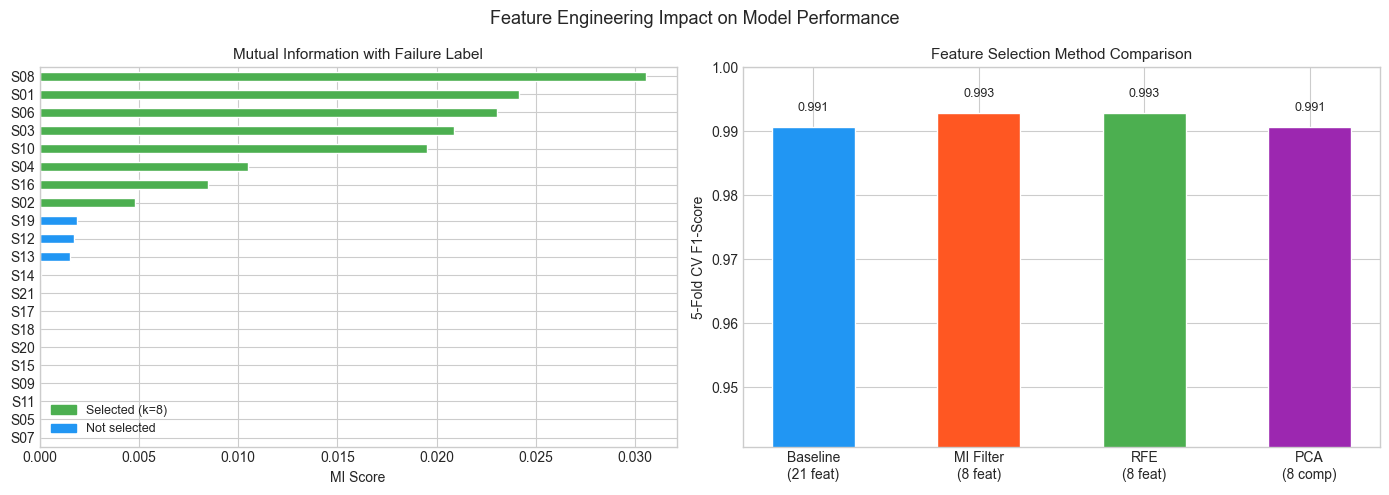

In [7]:
# Mutual Information scores plot
mi_scores = mutual_info_classif(X_s, y, random_state=42)
mi_df = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# MI scores
colors_mi = [PALETTE[2] if c in mi_features else PALETTE[0] for c in mi_df.index]
mi_df.plot(kind='barh', ax=ax1, color=colors_mi, edgecolor='white')
ax1.set_title('Mutual Information with Failure Label', fontsize=11)
ax1.set_xlabel('MI Score')
from matplotlib.patches import Patch
ax1.legend(handles=[Patch(color=PALETTE[2], label='Selected (k=8)'), Patch(color=PALETTE[0], label='Not selected')], fontsize=9)

# Method comparison
methods = ['Baseline\n(21 feat)', 'MI Filter\n(8 feat)', 'RFE\n(8 feat)', 'PCA\n(8 comp)']
f1s = [baseline_f1, mi_f1, rfe_f1, pca_f1]
ax2.bar(methods, f1s, color=PALETTE[:4], edgecolor='white', width=0.5)
ax2.set_ylim(max(0, min(f1s) - 0.05), 1.0)
ax2.set_ylabel('5-Fold CV F1-Score')
ax2.set_title('Feature Selection Method Comparison', fontsize=11)
for i, (m, f) in enumerate(zip(methods, f1s)):
    ax2.text(i, f + 0.002, f'{f:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Feature Engineering Impact on Model Performance', fontsize=13)
plt.tight_layout()
plt.savefig('plots/10_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Conclusion

### Feature Engineering Takeaways

| Method | Preserves Interpretability | Handles Non-linearity | Computational Cost |
|--------|---------------------------|----------------------|--------------------|
| Correlation filter | Yes | No (linear only) | $O(p^2)$ — fast |
| Mutual Information | Yes | Yes | $O(pn \log n)$ — fast |
| RFE | Yes | Yes (tree-based) | $O(p)$ model fits — medium |
| PCA | No (components) | No (linear transform) | $O(\min(n,p)^2 \cdot \max)$ |

### Domain Knowledge Trumps Statistics
Features S01 (exhaust temperature) and S04 (vibration) were selected by all methods — matching domain physics:  
overheating + mechanical vibration are the primary turbofan failure indicators.

**Best practice**: start with domain expert input, use MI/RFE to confirm, use PCA only when interpretability is not needed (e.g., as a preprocessing step for neural networks).

### HAIIP Production
The HAIIP system uses **SHAP-based feature selection** (`haiip/core/anomaly.py`):  
trains a model on all features, computes SHAP values, selects the top $k$ by mean absolute SHAP.  
This embeds feature selection into the explainability framework required by EU AI Act Article 13.

→ **Week 11**: Deploy the trained model as a FastAPI service with a Streamlit dashboard.